In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [4]:
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeaturesTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeaturesTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

In [6]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

K-Fold Validation

In [19]:
n_fold = 10

clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
)

cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)


In [21]:
#Testing on unseen data
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Explosion': 0, 'Gunshots': 1, 'UAV': 2, 'shortened_unlabeled': 3}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.7200
                     precision    recall  f1-score   support

          Explosion       0.53      0.64      0.58        75
           Gunshots       0.64      0.36      0.46        75
                UAV       0.93      0.95      0.94        75
shortened_unlabeled       0.77      0.93      0.84        75

           accuracy                           0.72       300
          macro avg       0.72      0.72      0.71       300
       weighted avg       0.72      0.72      0.71       300



Visualize

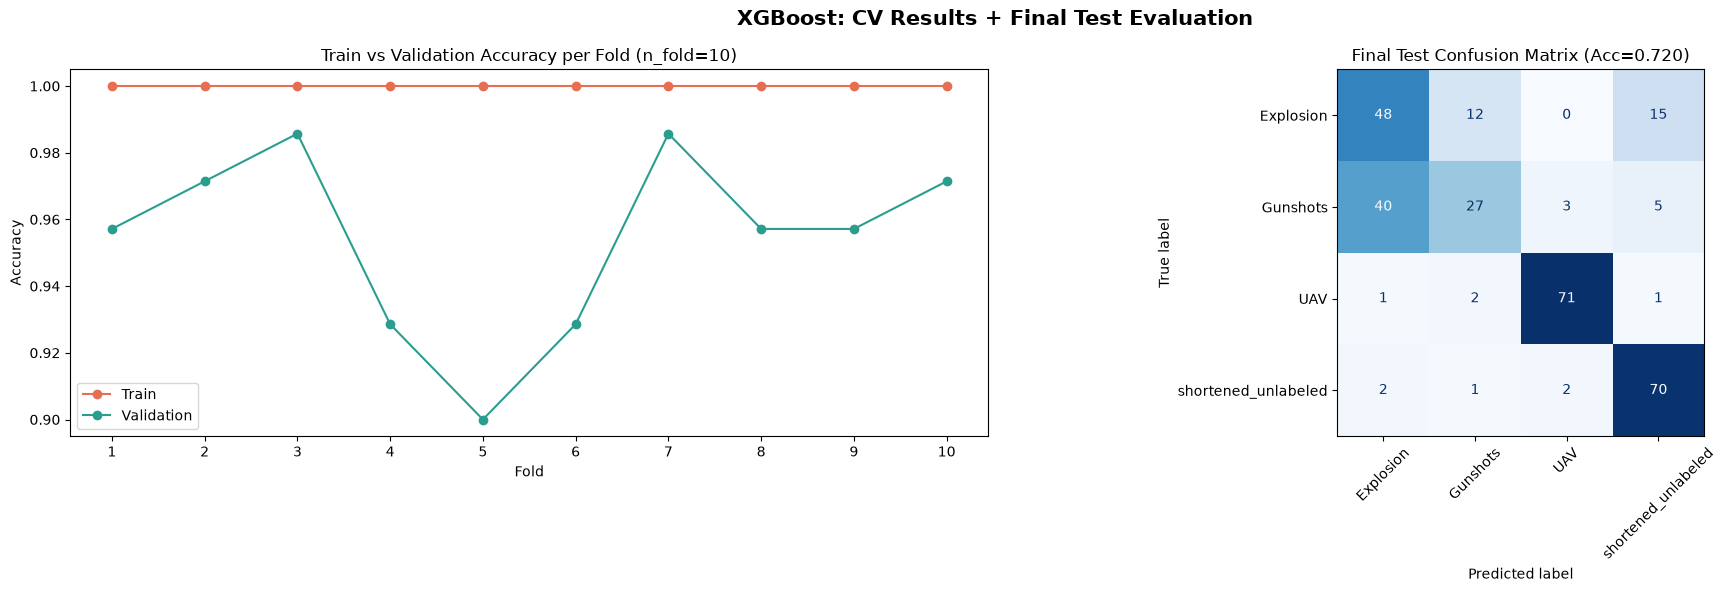

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("XGBoost: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# (a) Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, n_fold + 1)
ax.plot(folds, cv_results["train_score"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_score"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title(f"Train vs Validation Accuracy per Fold (n_fold={n_fold})")
ax.legend()

# (b) Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")

plt.tight_layout()
plt.show()

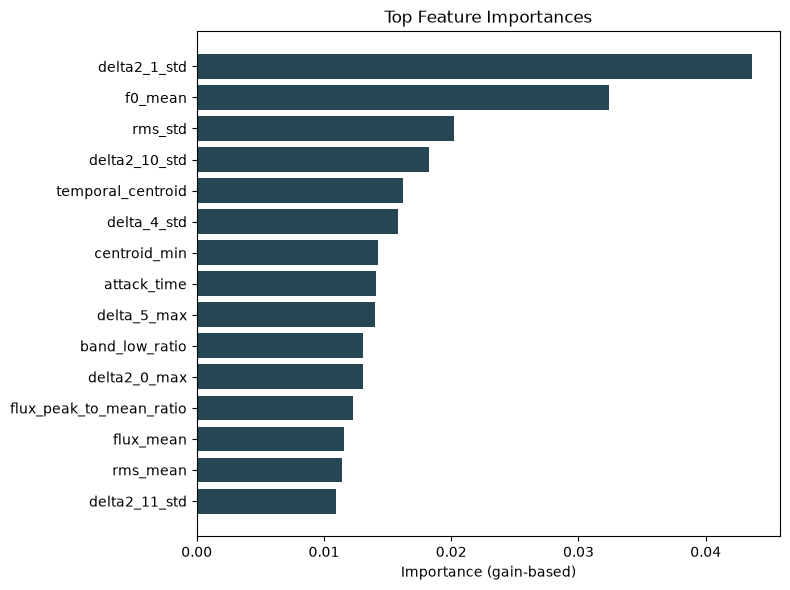

In [27]:
feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Parameter Tuning

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

n_classes = len(np.unique(y_train))

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# XGBoost has no class_weight param — use sample_weight instead to handle imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
random_search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = XGBClassifier(
    n_estimators=200,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42
)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV f1_macro score: 0.9501366952324769

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.7167
                     precision    recall  f1-score   support

          Explosion       0.55      0.65      0.60        75
           Gunshots       0.73      0.40      0.52        75
                UAV       0.91      0.89      0.90        75
shortened_unlabeled       0.72      0.92      0.81        75

           accuracy                           0.72       300
          macro avg       0.73      0.72      0.71       300
       weighted avg       0.73      0.72      0.71       300

Per-class recall (Default):
  Explosion                : 0.6533
  Gunshots                 : 0.4000
  UAV                      : 0.8933
  shortened_unlabeled      : 0.9200

=== Tuned 